In [1]:
import sys

print("Python version:", sys.version)
print("Python path:", sys.executable)

Python version: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Python path: C:\Users\T9951\Documents\ServiceSense_AI\.venv\Scripts\python.exe


In [2]:
%pip install pandas numpy scikit-learn matplotlib joblib

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 730.2 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.8 MB 730.2 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.8 MB 819.2 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.8 MB 883.6 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.8 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.8 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.8 MB 1.2 MB/s eta 0:00:07
   ---------- ----------------------------- 2.6/9.8 MB 1.3 MB/s eta 0:00:06
   ----------- ------------------------

In [3]:
%pip install sentence-transformers faiss-cpu langchain langchain-openai

   ---------------------------------------- 0.0/739.6 kB ? eta -:--:--
   -------------- ------------------------- 262.1/739.6 kB ? eta -:--:--
   ---------------------------------------- 739.6/739.6 kB 2.0 MB/s  0:00:00
   ---------------------------------------- 0.0/795.8 kB ? eta -:--:--
   -------------------------- ------------- 524.3/795.8 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 795.8/795.8 kB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.0 MB 3.7 MB/s eta 0:00:01
   --------------- ------------------------ 1.6/4.0 MB 3.8 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.0 MB 4.2 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.0 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 3.5 MB/s  0:00:01
   --------------------------

In [4]:
%pip install openai python-dotenv mlflow flask

   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
    --------------------------------------- 0.3/11.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.2 MB 1.0 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/11.2 MB 1.2 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/11.2 MB 1.0 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/11.2 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.2 MB 1.2 MB/s eta 0:00:08
   -------- ------------------------------- 2.4/11.2 MB 1.3 MB/s eta 0:00:07
   ---------- ----------------------------- 2.9/11.2 MB 1.4 MB/s eta 0:00:07
   ----------- ---------------------------- 3.1/11.2 MB 1.4 MB/s eta 0:00:06
   ------------- -------------------------- 3.7/11.2 MB 1.5 MB/s eta 0:00:06
   ----------

In [5]:
# Cell 1 - Import Libraries

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Cell 2 - Load ServiceSense Dataset

df = pd.read_csv("data/ServiceSenseAI.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (26872, 5)


In [7]:
# Cell 3 - Preview Dataset

df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [8]:
# Cell 4 - Dataset Information

print("Column Names:")

for i, column in enumerate(df.columns, start=1):
    print(i, column)

print("\nDataset Information:")
df.info()

Column Names:
1 flags
2 instruction
3 category
4 intent
5 response

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [9]:
# Cell 5 - Check Missing Values

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Duplicate Rows:
0


In [10]:
# Cell 6 - Select Required Columns

df_selected = df[
    ["instruction", "category", "intent", "response"]
].copy()

print("Selected dataset shape:", df_selected.shape)

df_selected.head()

Selected dataset shape: (26872, 4)


,instruction,category,intent,response
0,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [11]:
# Cell 7 - Category Analysis

print("Number of Categories:", df_selected["category"].nunique())

print("\nCategory Distribution:")
print(df_selected["category"].value_counts())

Number of Categories: 11

Category Distribution:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


In [12]:
# Cell 8 - Intent Analysis

print("Number of Intents:", df_selected["intent"].nunique())

print("\nIntent Distribution:")
print(df_selected["intent"].value_counts())

Number of Intents: 27

Intent Distribution:
intent
contact_customer_service    1000
complaint                   1000
check_invoice               1000
switch_account              1000
edit_account                1000
contact_human_agent          999
check_payment_methods        999
delivery_period              999
newsletter_subscription      999
get_invoice                  999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
set_up_shipping_address      997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
delivery_options             995
delete_account               995
recover_password             995
track_order                  995
change_shipping_address      973
check_cancellation_fee       950
Name: count, dtype: int64


In [13]:
# Cell 9 - Category Intent Relationship

category_intent = (
    df_selected[["category", "intent"]]
    .drop_duplicates()
    .sort_values(["category", "intent"])
)

category_intent

,category,intent
9913,ACCOUNT,create_account
10910,ACCOUNT,delete_account
13899,ACCOUNT,edit_account
19891,ACCOUNT,recover_password
20886,ACCOUNT,registration_problems
23879,ACCOUNT,switch_account
2968,CANCEL,check_cancellation_fee
7914,CONTACT,contact_customer_service
8914,CONTACT,contact_human_agent
11905,DELIVERY,delivery_options


In [14]:
# Cell 10 - View Complaint Examples

pd.set_option("display.max_colwidth", None)

df_selected[
    ["instruction", "category", "intent", "response"]
].sample(10, random_state=42)

,instruction,category,intent,response
9329,I can't talk with a human agent,CONTACT,contact_human_agent,Thank you for reaching out! I'm sorry to hear that you're facing difficulties in connecting with a human agent. Please rest assured that I'm here to assist you and resolve this issue. Could you please provide me with some more details about the problem you're experiencing? This will help me find the best solution for you.
4160,I have got to locate hte bills from {{Person Name}},INVOICE,check_invoice,"I'll get right on it! I understand your need to locate the bills associated with {{Person Name}}. To assist you in finding the relevant invoices, could you please provide me with some additional details such as the date range or any other specific information that might help narrow down the search? Rest assured, I'm here to guide you every step of the way and ensure a seamless experience."
18500,"I cannot pay, help me to inform of a problem with payments",PAYMENT,payment_issue,"I apologize for the inconvenience caused by the payment issue you're experiencing. I understand how frustrating it can be when you encounter difficulties while trying to make a payment. Rest assured, I'm here to assist you in resolving this problem. To help us further investigate and address the issue, could you please provide more details about the problem you are encountering? Any specific error messages or steps leading up to the issue would be helpful. Your input is valuable, and we're committed to finding a solution together. Thank you for bringing this to our attention, and we'll work diligently to get it sorted."
8840,I want help speaking to customer service,CONTACT,contact_customer_service,"Grateful for your contact! I get the sense that you're looking for assistance in speaking to our customer service team. I'm here to guide you through the process and ensure that you have a seamless experience. To connect with our customer service, you can reach them during {{Customer Support Hours}}. If you have any other questions, concerns, or experiences you'd like to share, please feel free to let me know. I'm here to help!"
5098,I try to see th accepted payment options,PAYMENT,check_payment_methods,"Thank you for reaching out! I completely understand that you tried to access the accepted payment options on our platform. I apologize for any inconvenience caused. Allow me to assist you in viewing our available payment methods.\n\nTo check the accepted payment options, you can visit our website's ""Payment"" or ""Checkout"" page. There, you will find a comprehensive list of the various payment methods we accept. If you encounter any difficulties or have further questions, please don't hesitate to let me know.\n\nYour satisfaction is our priority, and I'm here to ensure a seamless payment experience for you."
17250,where to sign up to the company nmewsletter,SUBSCRIPTION,newsletter_subscription,"Thank you for your interest in signing up for our company newsletter! To subscribe, you can visit our website at {{Website URL}} and navigate to the newsletter section. There you will find a sign-up form where you can enter your email address and other required information. Once you submit the form, you will be successfully subscribed to our newsletter and receive regular updates directly in your inbox. If you require any further assistance or have any questions, please don't hesitate to let me know."
3589,I'd like to see the withdrwaal fee how can i do it,CANCEL,check_cancellation_fee,"I'll do my best! To view the withdrawal fee, you can log in to your account and navigate to the ""Fee Schedule"" or ""Account Charges"" section. This will provide you with the details of the withdrawal fee and any associated charges."
9043,I want to speak with someone,CONTACT,contact_human_agent,"I see what you mean! I'm on the same page that you would like to speak with someone. Your request is important, and I'm here to help. Let me quickly connect you with a human representative who w

In [15]:
# Cell 11 - Text Preprocessing

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_selected["clean_instruction"] = (
    df_selected["instruction"].apply(clean_text)
)

df_selected[
    ["instruction", "clean_instruction", "intent"]
].head()

,instruction,clean_instruction,intent
0,question about cancelling order {{Order Number}},question about cancelling order order number,cancel_order
1,i have a question about cancelling oorder {{Order Number}},i have a question about cancelling oorder order number,cancel_order
2,i need help cancelling puchase {{Order Number}},i need help cancelling puchase order number,cancel_order
3,I need to cancel purchase {{Order Number}},i need to cancel purchase order number,cancel_order
4,"I cannot afford this order, cancel purchase {{Order Number}}",i cannot afford this order cancel purchase order number,cancel_order


In [16]:
# Cell 12 - Define ML Input and Target

X = df_selected["clean_instruction"]
y = df_selected["intent"]

print("Total records:", len(X))
print("Number of intent classes:", y.nunique())

Total records: 26872
Number of intent classes: 27


In [17]:
# Cell 13 - Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 21497
Testing records: 5375


In [18]:
# Cell 14 - TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words="english",
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

TF-IDF completed successfully!
Training shape: (21497, 11556)
Testing shape: (5375, 11556)


In [19]:
# Cell 15 - Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [20]:
# Cell 16 - Evaluate Logistic Regression

lr_predictions = logistic_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)

Logistic Regression Accuracy: 97.82 %

Classification Report:
                          precision    recall  f1-score   support

            cancel_order       1.00      0.95      0.97       200
            change_order       0.92      0.98      0.95       199
 change_shipping_address       0.98      1.00      0.99       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.83      0.88      0.85       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.99      0.98      0.99       200
          create_account       0.99      0.97      0.98       199
          delete_account       0.93      0.99      0.96       199
        delivery_options       1.00      1.00      1.00       199
         deli

In [21]:
# Cell 17 - Train Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tfidf,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


In [22]:
# Cell 18 - Evaluate Random Forest

rf_predictions = random_forest_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest Accuracy: 97.69 %

Classification Report:
                          precision    recall  f1-score   support

            cancel_order       0.99      0.98      0.98       200
            change_order       0.98      0.96      0.97       199
 change_shipping_address       0.97      0.99      0.98       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.79      0.86      0.83       200
   check_payment_methods       1.00      0.98      0.99       200
     check_refund_policy       1.00      0.99      0.99       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      0.98      0.99       200
     contact_human_agent       0.97      0.99      0.98       200
          create_account       0.97      0.98      0.98       199
          delete_account       0.99      0.98      0.99       199
        delivery_options       0.98      1.00      0.99       199
         delivery_p

In [23]:
# Cell 19 - Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(lr_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})

model_comparison = model_comparison.sort_values(
    "Accuracy (%)",
    ascending=False
)

model_comparison

,Model,Accuracy (%)
0,Logistic Regression,97.82
1,Random Forest,97.69


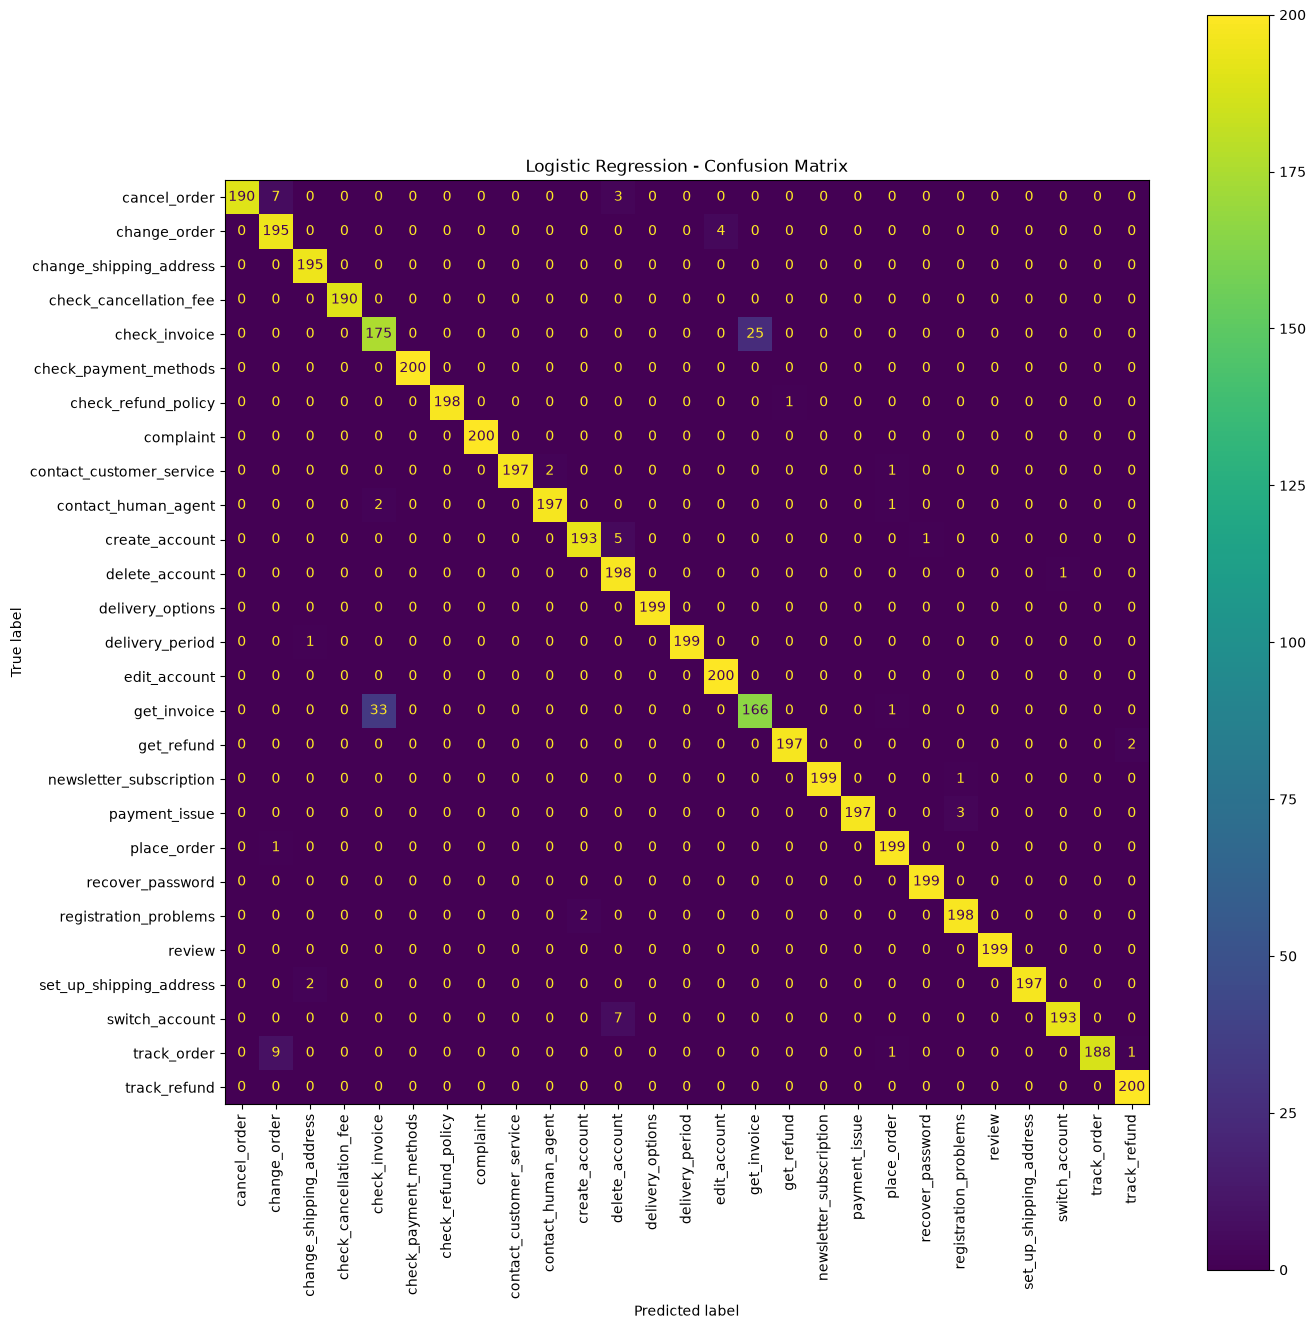

In [24]:
# Cell 20 - Logistic Regression Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    xticks_rotation=90,
    ax=ax
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
# Cell 21 - Select Best Model

if lr_accuracy >= rf_accuracy:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_accuracy = lr_accuracy
else:
    best_model = random_forest_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy

print("Best Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy * 100, 2), "%")

Best Model: Logistic Regression
Best Accuracy: 97.82 %


In [26]:
# Cell 22 - Save Trained Model

import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/intent_classifier.pkl"
)

joblib.dump(
    tfidf,
    "models/tfidf_vectorizer.pkl"
)

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!


In [27]:
# Cell 23 - Test Intent Prediction

def predict_intent(complaint):

    cleaned = clean_text(complaint)

    vector = tfidf.transform([cleaned])

    prediction = best_model.predict(vector)[0]

    return prediction


test_complaint = "I forgot my password and cannot access my account"

predicted_intent = predict_intent(test_complaint)

print("Customer Complaint:")
print(test_complaint)

print("\nPredicted Intent:")
print(predicted_intent)

Customer Complaint:
I forgot my password and cannot access my account

Predicted Intent:
recover_password


In [28]:
predict_intent("Where is my refund?")

'track_refund'

In [33]:
import os

git_path = r"C:\Program Files\Git\mingw64\bin\git.exe"

print("Git exists:", os.path.exists(git_path))

Git exists: True


In [34]:
import subprocess

result = subprocess.run(
    [git_path, "--version"],
    capture_output=True,
    text=True
)

print(result.stdout)

git version 2.54.0.windows.1



In [35]:
# Cell 28 - Initialize MLflow

import os

os.environ["GIT_PYTHON_GIT_EXECUTABLE"] = git_path
os.environ["GIT_PYTHON_REFRESH"] = "quiet"

import mlflow
import mlflow.sklearn

mlflow.set_experiment("ServiceSense_AI")

print("MLflow initialized successfully!")

MLflow initialized successfully!


In [36]:
# Cell 29 - Track Logistic Regression

with mlflow.start_run(run_name="Logistic_Regression"):

    mlflow.log_param("model_name", "Logistic Regression")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("tfidf_max_features", 15000)
    mlflow.log_param("ngram_range", "1,2")

    mlflow.log_metric("accuracy", lr_accuracy)

    mlflow.sklearn.log_model(
        logistic_model,
        name="logistic_regression_model"
    )

print("Logistic Regression experiment logged successfully!")

Logistic Regression experiment logged successfully!


In [37]:
# Cell 30 - Track Random Forest

with mlflow.start_run(run_name="Random_Forest"):

    mlflow.log_param("model_name", "Random Forest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("tfidf_max_features", 15000)

    mlflow.log_metric("accuracy", rf_accuracy)

    mlflow.sklearn.log_model(
        random_forest_model,
        name="random_forest_model"
    )

print("Random Forest experiment logged successfully!")

Random Forest experiment logged successfully!


In [38]:
# Cell 31 - MLflow Model Comparison

experiment = mlflow.get_experiment_by_name(
    "ServiceSense_AI"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

comparison_mlflow = runs[
    [
        "tags.mlflow.runName",
        "metrics.accuracy"
    ]
].copy()

comparison_mlflow["Accuracy (%)"] = (
    comparison_mlflow["metrics.accuracy"] * 100
).round(2)

comparison_mlflow[
    ["tags.mlflow.runName", "Accuracy (%)"]
]

,tags.mlflow.runName,Accuracy (%)
0,Random_Forest,97.69
1,Logistic_Regression,97.82
2,Logistic_Regression,97.82


In [39]:
# Cell 32 - Best Model Summary

best_run = comparison_mlflow.sort_values(
    "Accuracy (%)",
    ascending=False
).iloc[0]

print("Best Model:", best_run["tags.mlflow.runName"])
print("Accuracy:", best_run["Accuracy (%)"], "%")

Best Model: Logistic_Regression
Accuracy: 97.82 %


In [40]:
# Cell 33 - Import RAG Libraries

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("RAG libraries imported successfully!")

RAG libraries imported successfully!


In [43]:
# Cell 34 - Test Hugging Face Access

from huggingface_hub import hf_hub_download

test_file = hf_hub_download(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    filename="config.json"
)

print("Hugging Face Python access working!")
print(test_file)

Hugging Face Python access working!
C:\Users\T9951\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2\snapshots\1110a243fdf4706b3f48f1d95db1a4f5529b4d41\config.json


In [45]:
%pip install pip-system-certs

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Cell 35A - Test Hugging Face after certificate fix

from huggingface_hub import hf_hub_download

test_file = hf_hub_download(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    filename="config.json",
    force_download=True
)

print("Hugging Face certificate test passed!")
print(test_file)

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Hugging Face certificate test passed!
C:\Users\T9951\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2\snapshots\1110a243fdf4706b3f48f1d95db1a4f5529b4d41\config.json


In [3]:
# Cell 35A - Disable Hugging Face Xet

import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

print("Xet disabled:", os.environ["HF_HUB_DISABLE_XET"])

Xet disabled: 1


In [4]:
%whos

Variable              Type       Data/Info
------------------------------------------
SentenceTransformer   ABCMeta    <class 'sentence_transfor<...>del.SentenceTransformer'>
faiss                 module     <module 'faiss' from 'C:\<...>ges\\faiss\\__init__.py'>
np                    module     <module 'numpy' from 'C:\<...>ges\\numpy\\__init__.py'>


In [6]:
import pandas as pd

df = pd.read_csv("data/ServiceSenseAI.csv")

print(df.shape)
print(df.columns.tolist())

(26872, 5)
['flags', 'instruction', 'category', 'intent', 'response']


In [7]:
df_selected = df[
    ["instruction", "category", "intent", "response"]
].copy()

print(df_selected.shape)

(26872, 4)


In [8]:
import joblib

tfidf = joblib.load(
    "models/tfidf_vectorizer.pkl"
)

print("TF-IDF loaded successfully!")

TF-IDF loaded successfully!


In [9]:
print("Dataset:", df_selected.shape)
print("TF-IDF:", tfidf)

Dataset: (26872, 4)
TF-IDF: TfidfVectorizer(max_features=15000, ngram_range=(1, 2), stop_words='english',
                sublinear_tf=True)


In [10]:
# Cell 35 - Create RAG TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

rag_tfidf = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1, 2)
)

rag_vectors = rag_tfidf.fit_transform(
    df_selected["instruction"]
)

print("RAG TF-IDF shape:", rag_vectors.shape)

RAG TF-IDF shape: (26872, 2000)


In [11]:
# Cell 36 - Prepare FAISS Vectors

rag_vectors_dense = rag_vectors.toarray().astype("float32")

print("Dense vector shape:", rag_vectors_dense.shape)
print("Data type:", rag_vectors_dense.dtype)

Dense vector shape: (26872, 2000)
Data type: float32


In [12]:
# Cell 37 - Normalize RAG Vectors

import faiss

faiss.normalize_L2(rag_vectors_dense)

print("Vectors normalized successfully!")

Vectors normalized successfully!


In [13]:
# Cell 38 - Build FAISS Index

dimension = rag_vectors_dense.shape[1]

faiss_index = faiss.IndexFlatIP(dimension)

faiss_index.add(rag_vectors_dense)

print("FAISS index created successfully!")
print("Total vectors:", faiss_index.ntotal)

FAISS index created successfully!
Total vectors: 26872


In [14]:
# Cell 39 - Retrieve Similar Complaints

def retrieve_similar_complaints(query, top_k=3):

    query_vector = rag_tfidf.transform([query]).toarray().astype("float32")

    faiss.normalize_L2(query_vector)

    scores, indices = faiss_index.search(
        query_vector,
        top_k
    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        row = df_selected.iloc[idx]

        results.append({
            "score": float(score),
            "instruction": row["instruction"],
            "category": row["category"],
            "intent": row["intent"],
            "response": row["response"]
        })

    return results

In [15]:
# Cell 40 - Test RAG Retrieval

test_query = "I forgot my password and cannot login"

results = retrieve_similar_complaints(
    test_query,
    top_k=3
)

for i, result in enumerate(results, 1):

    print(f"\nResult {i}")

    print("Similarity:", round(result["score"], 3))
    print("Complaint:", result["instruction"])
    print("Intent:", result["intent"])
    print("Response:", result["response"])


Result 1
Similarity: 0.702
Complaint: I forgot my account password, how t reset it?
Intent: recover_password
Response: Oh, I completely understand how frustrating it can be to forget your account password. Don't worry, I'm here to assist you in the process of resetting it so you can regain access to your account. Here's what you can do:

1. First and foremost, visit our login page at "{{Login Page URL}}" to initiate the password reset process.
2. Look for the option that says "{{Forgot Password}}" and click on it.
3. You will be prompted to enter the email address associated with your account. Please provide the correct email address to proceed.
4. Once you've entered your email address, an email will be sent to you shortly with instructions on how to reset your password. Please check your inbox, as well as your spam or junk folder, just in case.
5. Follow the instructions in the email to create a new password. Make sure to choose a strong and unique password to enhance the security o

In [16]:
# Cell 41 - OpenAI API Setup

%pip install openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [17]:
from pathlib import Path

Path(".env").touch(exist_ok=True)

print("Created:", Path(".env").resolve())

Created: C:\Users\T9951\Documents\ServiceSense_AI\.env


In [18]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")

print("API key loaded:", bool(api_key))

API key loaded: True


In [19]:
from openai import OpenAI

client = OpenAI(api_key=api_key)

response = client.responses.create(
    model="gpt-5-mini",
    input="Reply with exactly: ServiceSense AI API is working"
)

print(response.output_text)

APIConnectionError: Connection error.

In [20]:
import os

print("HTTP_PROXY :", os.getenv("HTTP_PROXY"))
print("HTTPS_PROXY:", os.getenv("HTTPS_PROXY"))
print("ALL_PROXY  :", os.getenv("ALL_PROXY"))

HTTP_PROXY : None
HTTPS_PROXY: None
ALL_PROXY  : None


In [21]:
import requests

try:
    r = requests.get("https://api.openai.com/v1/models", timeout=15)
    print("Status code:", r.status_code)
    print(r.text[:300])
except Exception as e:
    print(type(e).__name__)
    print(e)

Status code: 401
{
  "error": {
    "message": "Missing bearer authentication in header",
    "type": "invalid_request_error",
    "param": null,
    "code": null
  }
}


In [22]:
import openai
import httpx

print("OpenAI version:", openai.__version__)
print("httpx version:", httpx.__version__)

OpenAI version: 3.5.0
httpx version: 0.28.1


In [23]:
from openai import OpenAI

client = OpenAI(
    api_key=api_key,
    max_retries=0,
    timeout=30.0
)

try:
    response = client.responses.create(
        model="gpt-5-mini",
        input="Say only: API working"
    )

    print(response.output_text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

ERROR TYPE: APIConnectionError
ERROR: Connection error.


In [24]:
import httpx

try:
    r = httpx.get(
        "https://api.openai.com/v1/models",
        timeout=15
    )

    print("Status code:", r.status_code)
    print(r.text[:200])

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

Status code: 401
{
  "error": {
    "message": "Missing bearer authentication in header",
    "type": "invalid_request_error",
    "param": null,
    "code": null
  }
}


In [25]:
import os

print("API key exists:", bool(api_key))
print("API key type:", type(api_key).__name__)
print("API key starts with:", api_key[:3] if api_key else "None")

print("OPENAI_BASE_URL:", os.getenv("OPENAI_BASE_URL"))
print("OPENAI_API_BASE:", os.getenv("OPENAI_API_BASE"))

API key exists: True
API key type: str
API key starts with: sk-
OPENAI_BASE_URL: None
OPENAI_API_BASE: None


In [26]:
import httpx
from openai import OpenAI

legacy_http_client = httpx.Client(
    timeout=30.0,
    follow_redirects=True
)

client = OpenAI(
    api_key=api_key,
    http_client=legacy_http_client,
    max_retries=0
)

try:
    response = client.responses.create(
        model="gpt-5-mini",
        input="Reply only: ServiceSense AI API is working"
    )

    print(response.output_text)

except Exception as e:
    print("ERROR TYPE:", type(e).__name__)
    print("ERROR:", str(e))

ERROR TYPE: RateLimitError
ERROR: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using the API at https://platform.openai.com/settings/organization/billing/.', 'type': 'insufficient_quota', 'param': None, 'code': 'credit_balance_exhausted'}}


In [27]:
def suggest_resolution(query):
    results = retrieve_similar_complaints(query, top_k=3)

    best_result = results[0]

    print("Customer Complaint:")
    print(query)

    print("\nDetected Intent:")
    print(best_result["intent"])

    print("\nSuggested Resolution:")
    print(best_result["response"])

    print("\nSimilarity Score:")
    print(round(best_result["score"], 3))


suggest_resolution(
    "I forgot my password and cannot access my account"
)

Customer Complaint:
I forgot my password and cannot access my account

Detected Intent:
recover_password

Suggested Resolution:
Oh, I completely understand how frustrating it can be to forget your account password. Don't worry, I'm here to assist you in the process of resetting it so you can regain access to your account. Here's what you can do:

1. First and foremost, visit our login page at "{{Login Page URL}}" to initiate the password reset process.
2. Look for the option that says "{{Forgot Password}}" and click on it.
3. You will be prompted to enter the email address associated with your account. Please provide the correct email address to proceed.
4. Once you've entered your email address, an email will be sent to you shortly with instructions on how to reset your password. Please check your inbox, as well as your spam or junk folder, just in case.
5. Follow the instructions in the email to create a new password. Make sure to choose a strong and unique password to enhance the se

In [28]:
import joblib
import faiss

joblib.dump(
    rag_tfidf,
    "models/rag_tfidf_vectorizer.pkl"
)

faiss.write_index(
    faiss_index,
    "models/complaints_faiss.index"
)

print("RAG components saved successfully!")
print("✓ TF-IDF vectorizer saved")
print("✓ FAISS index saved")

RAG components saved successfully!
✓ TF-IDF vectorizer saved
✓ FAISS index saved


In [29]:
import os
print(os.listdir("models"))

['complaints_faiss.index', 'intent_classifier.pkl', 'rag_tfidf_vectorizer.pkl', 'tfidf_vectorizer.pkl']


In [30]:
import joblib
import faiss

intent_model = joblib.load("models/intent_classifier.pkl")
intent_tfidf = joblib.load("models/tfidf_vectorizer.pkl")

rag_tfidf = joblib.load("models/rag_tfidf_vectorizer.pkl")
faiss_index = faiss.read_index("models/complaints_faiss.index")

print("All final models loaded successfully!")

All final models loaded successfully!


In [31]:
def servicesense_ai(complaint):

    # 1. Predict intent using ML model
    complaint_vector = intent_tfidf.transform([complaint])
    predicted_intent = intent_model.predict(complaint_vector)[0]

    # 2. Retrieve similar complaints using FAISS
    rag_vector = rag_tfidf.transform([complaint]).toarray().astype("float32")
    faiss.normalize_L2(rag_vector)

    scores, indices = faiss_index.search(rag_vector, 3)

    best_idx = indices[0][0]
    best_score = scores[0][0]

    best_match = df_selected.iloc[best_idx]

    # 3. Show result
    print("=" * 60)
    print("                 ServiceSense AI")
    print("=" * 60)

    print("\nCustomer Complaint:")
    print(complaint)

    print("\nPredicted Intent:")
    print(predicted_intent)

    print("\nRetrieved Similar Complaint:")
    print(best_match["instruction"])

    print("\nSuggested Resolution:")
    print(best_match["response"])

    print("\nSimilarity Score:")
    print(round(float(best_score), 3))

    print("=" * 60)

In [32]:
servicesense_ai(
    "I made a payment but the money was deducted and the payment failed"
)

                 ServiceSense AI

Customer Complaint:
I made a payment but the money was deducted and the payment failed

Predicted Intent:
payment_issue

Retrieved Similar Complaint:
I have a queston about the payment

Suggested Resolution:
Grateful you reached out with your question about the payment. I'm here to assist you. Please go ahead and let me know what specific question you have, and I'll provide you with the necessary information or guidance to address your concerns.

Similarity Score:
0.856


In [33]:
import os
print(os.listdir("data"))

['ServiceSenseAI.csv']
